In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully ✅
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing values
df['country'].fillna('Unknown', inplace=True)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)

df.isnull().sum()

/tmp/ipykernel_13468/11298881.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipykernel_13468/11298881.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,3


In [6]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


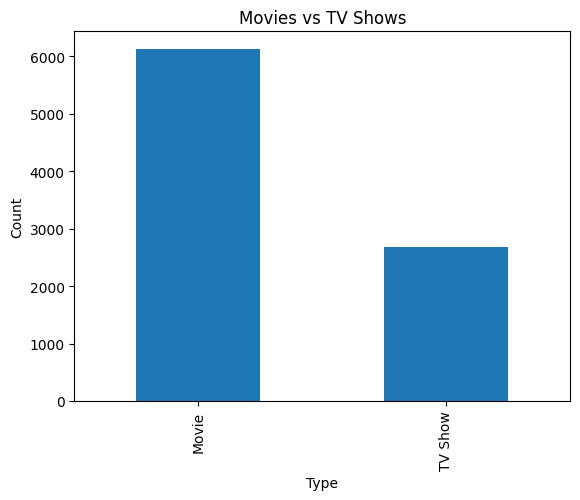

In [7]:
import matplotlib.pyplot as plt

type_count = df['type'].value_counts()

type_count.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

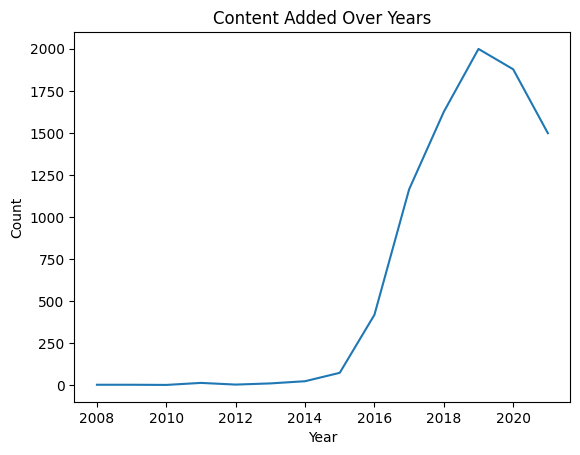

In [8]:
content_year = df['year_added'].value_counts().sort_index()

content_year.plot()
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


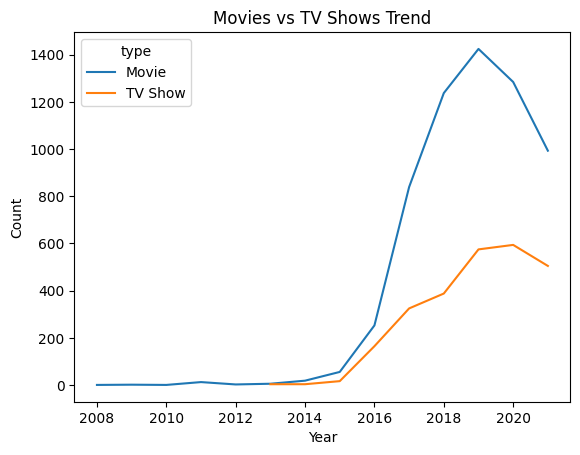

In [9]:
type_year = df.groupby(['year_added', 'type']).size().unstack()

type_year.plot()
plt.title("Movies vs TV Shows Trend")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

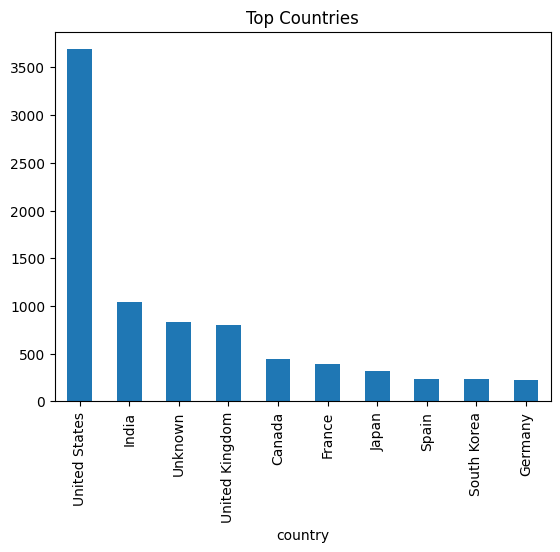

In [10]:
countries = df['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.show()

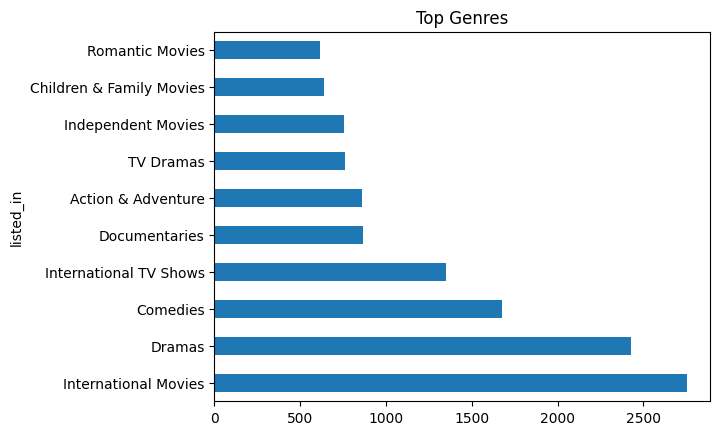

In [11]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

top_genres.plot(kind='barh')
plt.title("Top Genres")
plt.show()


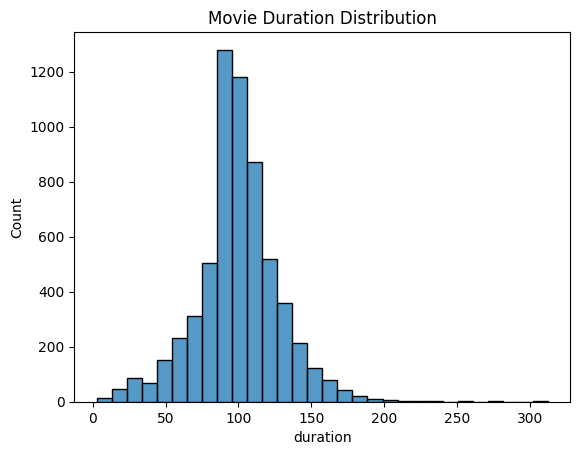

In [12]:
import seaborn as sns

movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

sns.histplot(movies['duration'].dropna(), bins=30)
plt.title("Movie Duration Distribution")
plt.show()

In [13]:
actors = df['cast'].str.split(', ').explode()
top_actors = actors.value_counts().head(10)

top_actors

,count
cast,
Unknown,825
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Naseeruddin Shah,32
Takahiro Sakurai,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30


In [14]:
def recommend_by_genre(genre):
    return df[df['listed_in'].str.contains(genre, na=False)][['title', 'listed_in']].head(10)

recommend_by_genre("Dramas")

,title,listed_in
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries"
5,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries"
7,Sankofa,"Dramas, Independent Movies, International Movies"
9,The Starling,"Comedies, Dramas"
12,Je Suis Karl,"Dramas, International Movies"
15,Dear White People,"TV Comedies, TV Dramas"
17,Falsa identidad,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
21,Resurrection: Ertugrul,"International TV Shows, TV Action & Adventure,..."
30,Ankahi Kahaniya,"Dramas, Independent Movies, International Movies"
33,Squid Game,"International TV Shows, TV Dramas, TV Thrillers"


In [15]:
print("=== FINAL INSIGHTS ===")

print("Total Content:", df.shape[0])
print("Most Common Type:", df['type'].value_counts().idxmax())
print("Top Genre:", top_genres.index[0])
print("Top Country:", top_countries.index[0])
print("Top Actor:", top_actors.index[0])

=== FINAL INSIGHTS ===
Total Content: 8807
Most Common Type: Movie
Top Genre: International Movies
Top Country: United States
Top Actor: Unknown
